# Bài tập thực hành tuần 2
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

### Bài tập 1:
**Câu hỏi**:

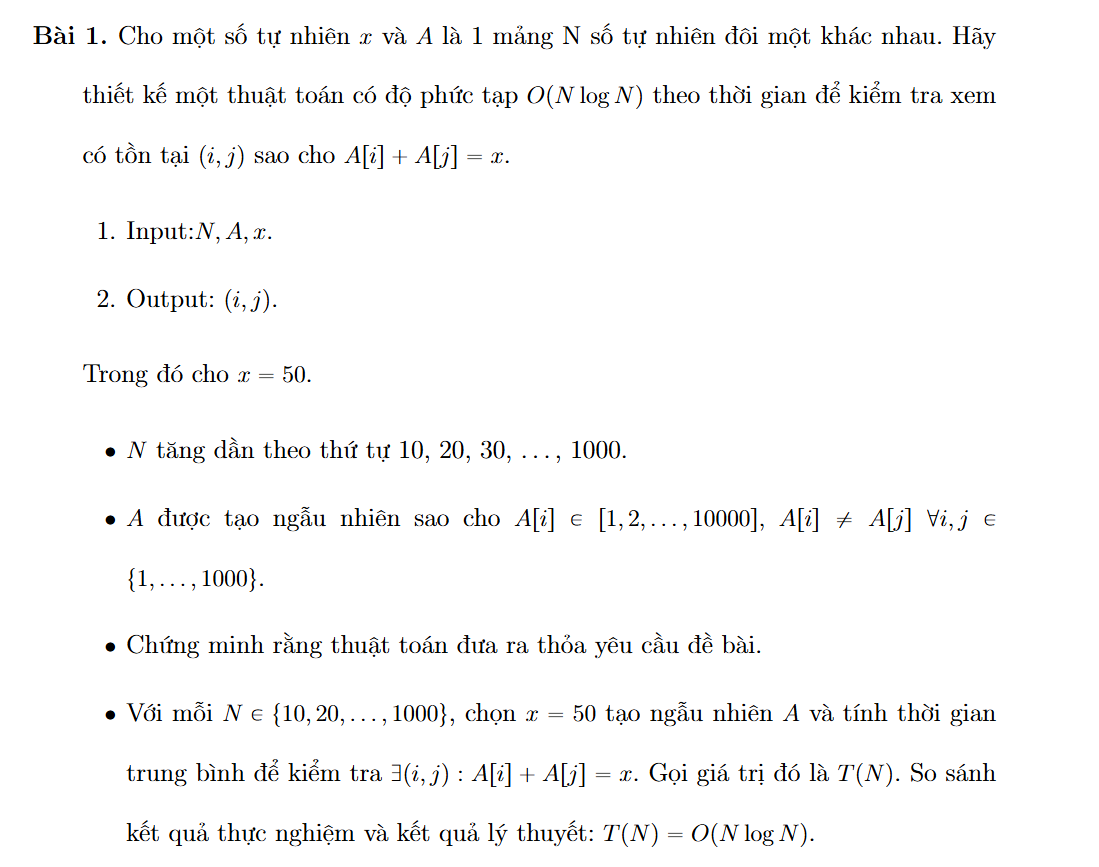

```python
import time
import numpy as np
import matplotlib.pyplot as plt

def quick_sort(arr):
    if len(arr) <= 1:
        return arr

    pivot_val = arr[len(arr) // 2][0]
    left = [x for x in arr if x[0] < pivot_val]
    middle = [x for x in arr if x[0] == pivot_val]
    right = [x for x in arr if x[0] > pivot_val]

    return quick_sort(left) + middle + quick_sort(right)
def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])

    return merge(left_half, right_half)
def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i][0] < right[j][0]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    
    return result
def algorithm(N, A, x, method = 1):
    A_indexed = [(A[i], i) for i in range(N)]
    
    if method == 1:
        sorted_A = quick_sort(A_indexed)
    else:
        sorted_A = merge_sort(A_indexed)

    left, right = 0, N - 1
    
    while left < right:
        current_sum = sorted_A[left][0] + sorted_A[right][0]       
        if current_sum == x:
            return (sorted_A[left][1], sorted_A[right][1])
        elif current_sum < x:
            left += 1
        else:
            right -= 1
    return None


def calc_time(N, x, num_trials=100, method=1):
    total_time = 0
    for _ in range(num_trials):
        A = np.random.choice(np.arange(1, 10001), size=N, replace=False)
        
        start_time = time.perf_counter()
        algorithm(N, A, x, method=method)
        end_time = time.perf_counter()
        
        total_time += (end_time - start_time)
        
    return total_time / num_trials

def test():
    x = 50
    N = np.arange(10, 1001, 10)
    
    plt.figure(figsize=(10, 6))
    colors = {1: 'blue', 2: 'green'}
    labels = {1: 'Quick Sort', 2: 'Merge Sort'}
    
    plot_time = [calc_time(n, x, num_trials=5, method=1) for n in N]
    c = plot_time[-1] / (N[-1] * np.log(N[-1]))
    nlogn_time = c * N * np.log(N)
    plt.plot(N, nlogn_time, linestyle='--', color='red', label=r'Lý thuyết $O(N \log N)$')

    for method in [1, 2]:
        test_times = []
        print(f"\nRunning {labels[method]}")
        for n in N:
            avg_time = calc_time(n, x, num_trials=100, method=method)
            test_times.append(avg_time)
            # print(f"N = {n}, avg_time: {avg_time:.8f}")
            
        plt.plot(N, test_times, marker='o', markersize=3, color=colors[method], label=f'Thực nghiệm ({labels[method]})')

    plt.title('Quick Sort & Merge Sort vs O(N log N)')
    plt.xlabel('N')
    plt.ylabel('time (s)')
    plt.legend()
    plt.show()
test()
```
Note: quick sort và merge sort là các thuật toán sắp xếp có độ phức tạp trung bình O(N log N) đã học ở DSA nên sẽ không giải thích thêm.


Thuật toán đề xuất trong đề bài có độ phức tạp O(N log N) do:
- Bước 1: Tạo mảng A_indexed có độ phức tạp O(N).
- Bước 2: Sắp xếp mảng A_indexed bằng quick sort hoặc merge sort có độ phức tạp O(N log N).
- Bước 3: Thuật toán 2 con trỏ có độ phức tạp O(N) trong trường hợp x không tồn tại, hoặc O(1) nếu tìm thấy cặp phần tử sớm.
Do đó, tổng thể thuật toán có độ phức tạp O(N log N) do bước sắp xếp chiếm ưu thế. 


Do bài toán yêu cầu tìm cặp phần tử (i,j) sao cho A[i] + A[j] = x vì vậy ta bắt buộc phải sắp xếp mảng và gán lại chỉ số như trong A_indexed để mà khi tìm cặp i, j thỏa mãn thì ta có thể trả về đúng vị trí ban đầu của chúng trong mảng A.

```python
A_indexed = [(A[i], i) for i in range(N)]

A = [3, 47, 10]
A_indexed = [(3,0), (47,1), (10,2)]
sorted_A = [(3,0), (10,2), (47,1)]
```

Ý tưởng